# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

In [5]:
df.head(3)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.0,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN


In [28]:
df['Freight Cost (USD)'].value_counts()

Freight Included in Commodity Cost    1393
Invoiced Separately                    239
9736.1                                  36
6147.18                                 27
7445.8                                  16
                                      ... 
33008.05                                 1
51243.69                                 1
654.72                                   1
2478.87                                  1
See DN-4282 (ID#:83919)                  1
Name: Freight Cost (USD), Length: 6474, dtype: int64

In [6]:
df.shape

(10324, 33)

## Missing Values

In [7]:
df.isnull().sum().sort_values(ascending=False).head()

Dosage                       1736
Shipment Mode                 360
Line Item Insurance (USD)     287
Molecule/Test Type              0
Brand                           0
dtype: int64

In [8]:
df.dropna(subset=['Shipment Mode'], inplace=True)

In [9]:
df.isnull().sum().sort_values(ascending=False).head()

Dosage                       1685
Line Item Insurance (USD)     181
Vendor                          0
Freight Cost (USD)              0
Weight (Kilograms)              0
dtype: int64

## Outliers

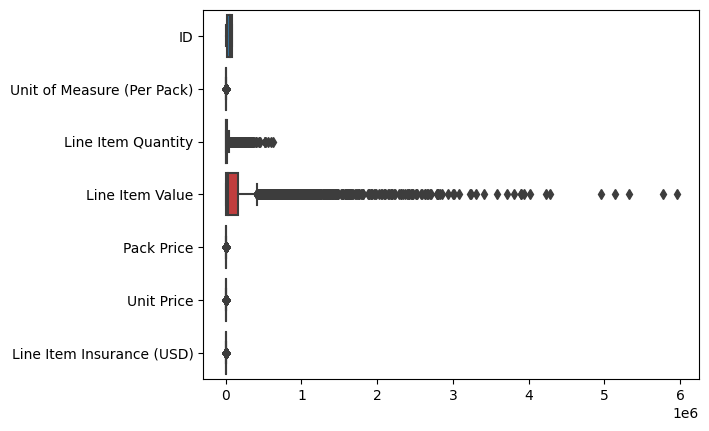

In [10]:
sns.boxplot(df.select_dtypes(include=['int','float']),orient='h')
plt.show()

## Correlation Analysis

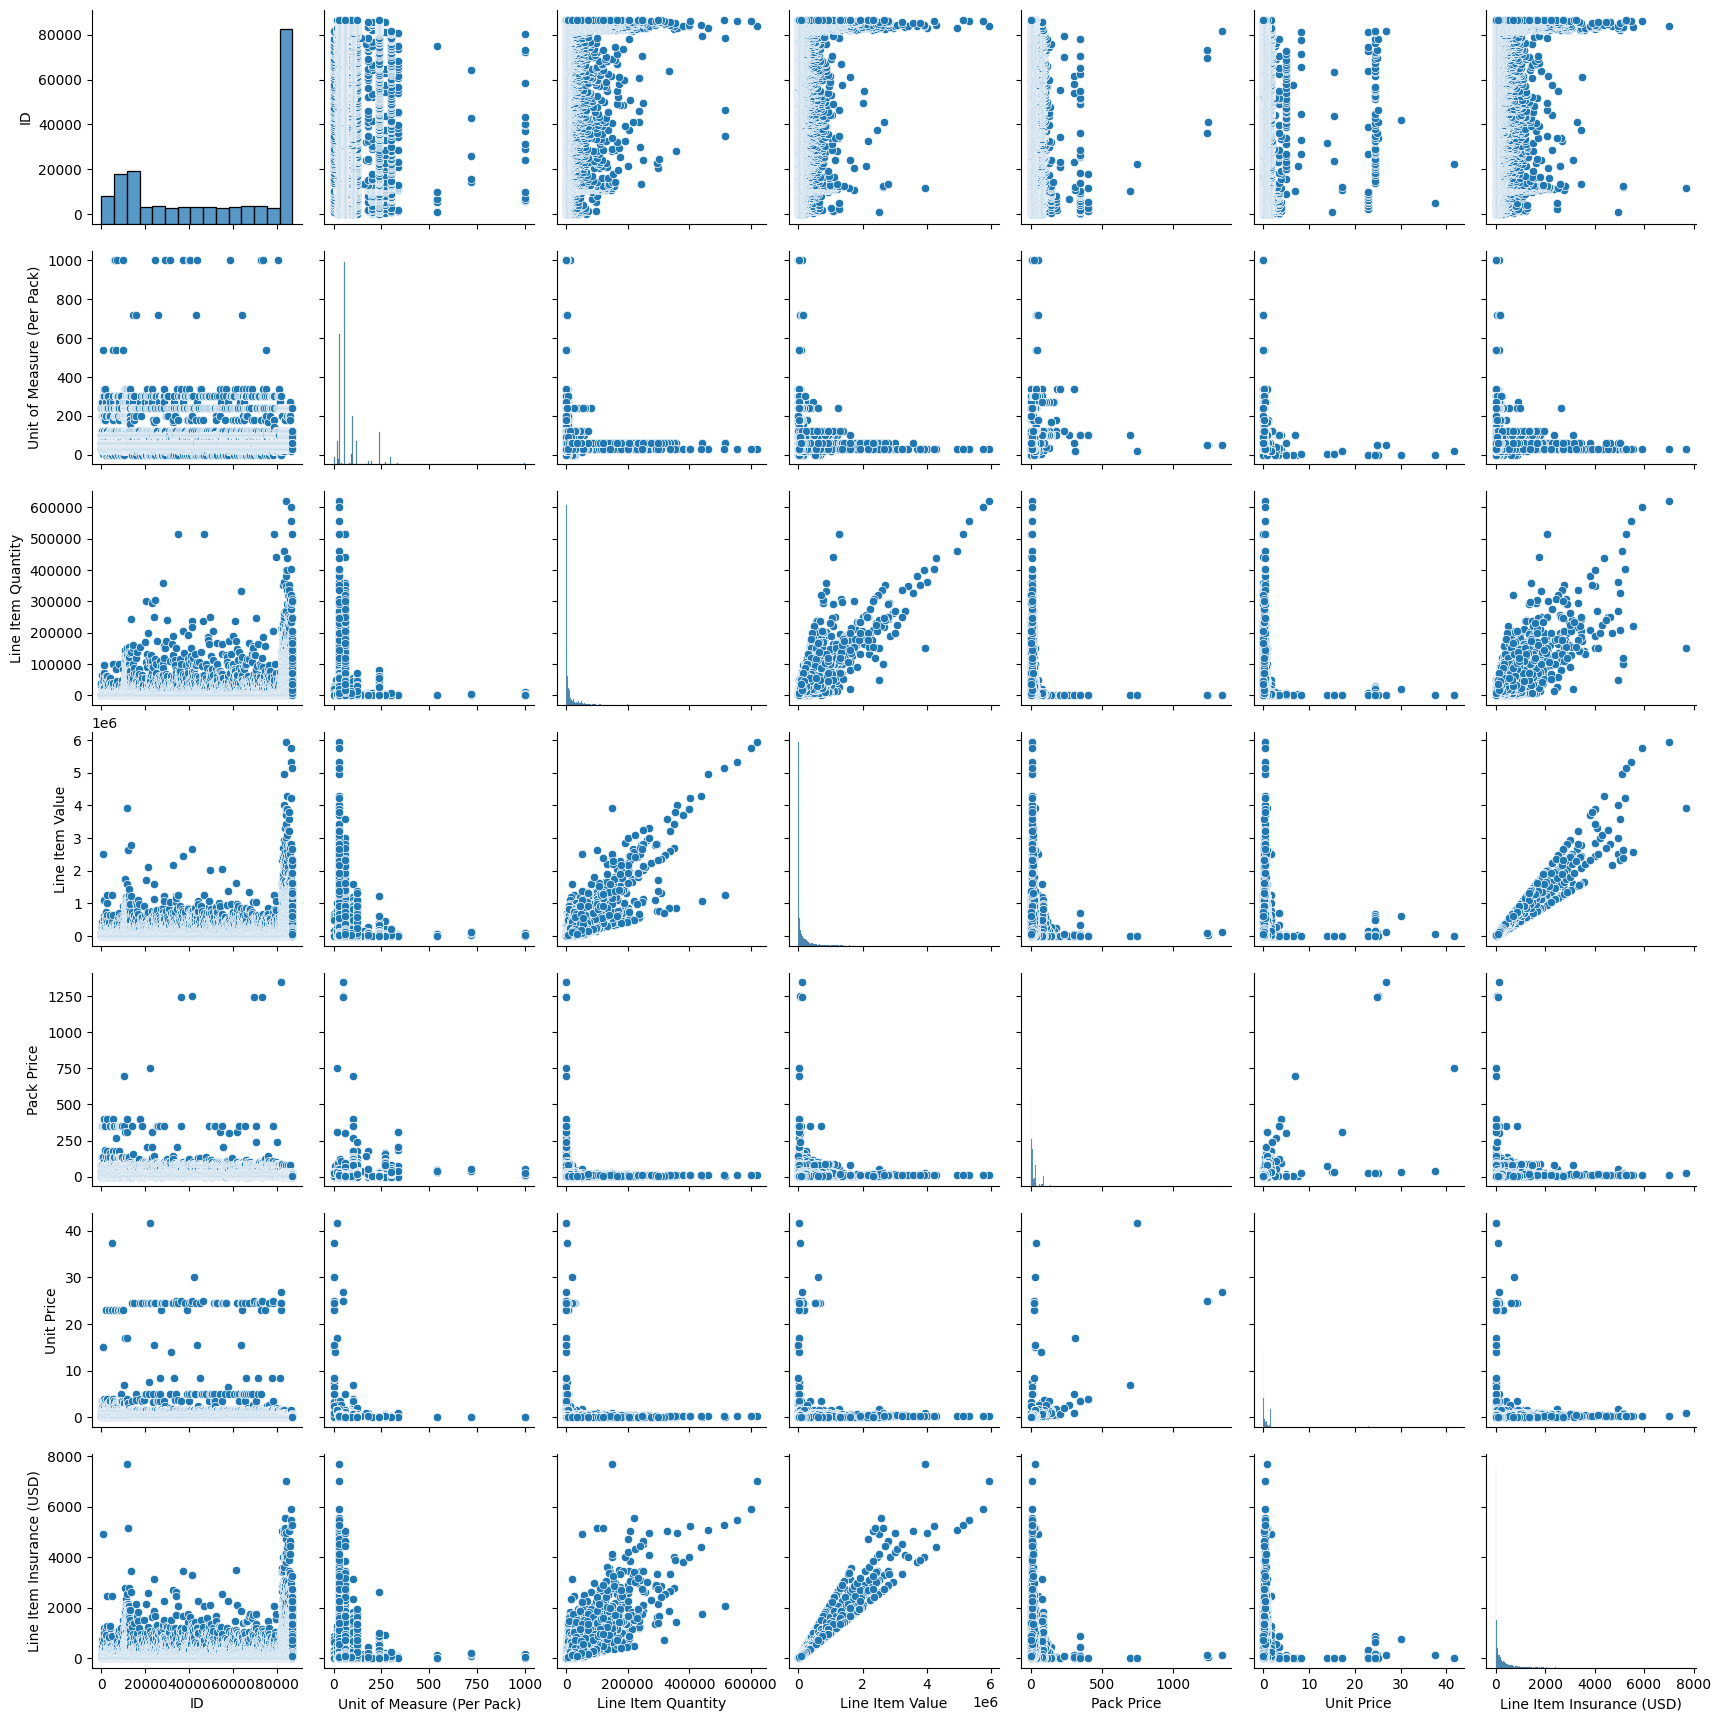

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

In [25]:
df.corr(numeric_only=True).columns

Index(['ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price',
       'Line Item Insurance (USD)'],
      dtype='object')

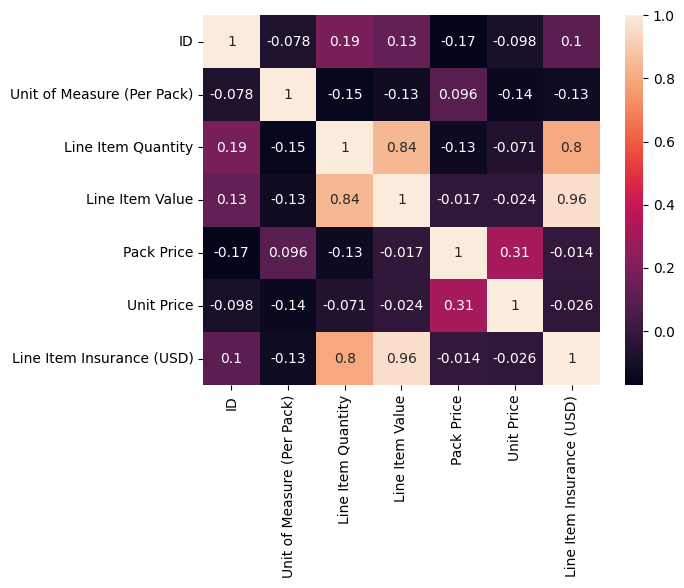

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [13]:
#  'Line Item Quantity', 'Line Item Value', 'Pack Price'

## Features Selection

### Numeric Features

In [14]:
def num_target(df, target='Shipment Mode'):
    
    num_cols = df.select_dtypes(include=['int','float']).columns
    
    return df.groupby(target)[num_cols].mean().reset_index()

In [15]:
num_target(df)

,Shipment Mode,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
0,Air,44947.163586,82.342549,9143.640275,102615.072379,27.984085,0.816660,162.401546
1,Air Charter,75009.315385,55.415385,45352.953846,379034.201769,8.638462,0.187400,543.556585
2,Ocean,47649.401617,71.832884,65314.692722,340102.274367,6.568949,0.152480,567.808518
3,Truck,64488.961837,72.593640,26803.161484,207555.607456,13.230212,0.251201,294.259442


### Categorical Features

In [16]:
df.select_dtypes(include=['object']).columns

Index(['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Manufacturing Site', 'First Line Designation',
       'Weight (Kilograms)', 'Freight Cost (USD)'],
      dtype='object')

In [17]:
df.sample(3)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
9758,86095,100-ZM-T30,FPQ-13679,SO-48020,DN-3754,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,29440,138368.00,4.70,0.16,"Aurobindo Unit VII, IN",Yes,2438,5236.92,142.24
9488,85781,109-TZ-T30,FPQ-7675,SO-39751,DN-2314,Tanzania,PMO - US,From RDC,N/A - From RDC,Air,...,30,4279,28113.03,6.57,0.22,Mylan (formerly Matrix) Nashik,Yes,259,1553.64,46.39
1762,11601,104-CI-T01,Pre-PQ Process,SO-11831,DN-949,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Air,...,60,21542,84013.80,3.90,0.06,Mylan (formerly Matrix) Nashik,Yes,1583,6381.87,164.67


In [18]:
df_clean = df[df['Weight (Kilograms)'] != 'Weight Captured Separately'].copy()
df_clean['Weight (Kilograms)'] = df_clean['Weight (Kilograms)'].astype(str).str.extract(r'(\d+\.?\d*)')
df_clean['Weight (Kilograms)'] = pd.to_numeric(df_clean['Weight (Kilograms)'])

In [19]:
df_clean.shape

(8504, 33)

In [20]:
# 'Country','Vendor','Product Group','Weight (Kilograms)

In [21]:
df_clean.groupby(['Country']).agg(Total_Shipments=('ID','count')).reset_index().sort_values(by='Total_Shipments',ascending=False).head(5)

,Country,Total_Shipments
24,Nigeria,1123
7,Côte d'Ivoire,946
35,Uganda,755
36,Vietnam,652
14,Haiti,599


In [22]:
# add the EDA from shipment price analysis project using python

# Final Data

In [23]:
final_df = df_clean[['Line Item Quantity', 'Line Item Value', 'Pack Price','Country','Vendor','Product Group','Weight (Kilograms)','Shipment Mode']]

In [24]:
final_df.to_csv('shipment_price.csv',index=False)